In [3]:
#Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Step 2: Load Dataset

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
#Step 3: Basic Info

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
#Data cleaning

# Fill missing values (SAFE METHOD)
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# Drop rows with very few missing values
df = df.dropna(subset=['date_added', 'duration'])

# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year
df['year_added'] = df['date_added'].dt.year
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      88
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      88
dtype: int64

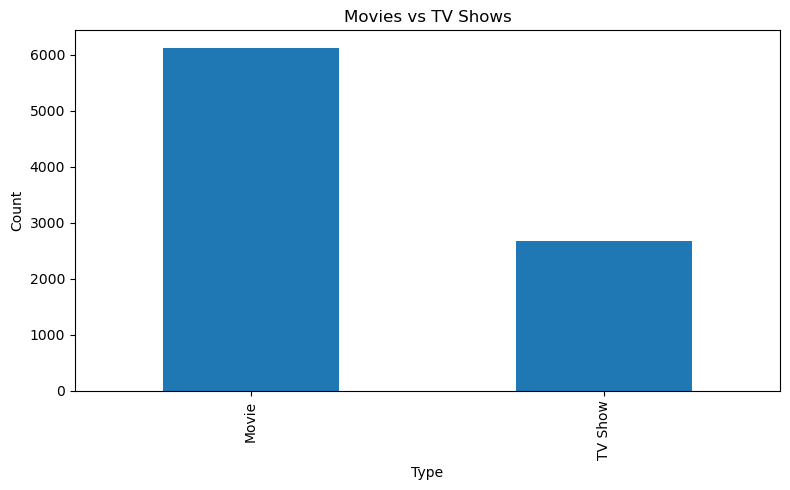

In [7]:
#Movies vs TV Shows (with % insight)
plt.figure(figsize=(8,5))

df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("images/type_distribution.png")
plt.show()

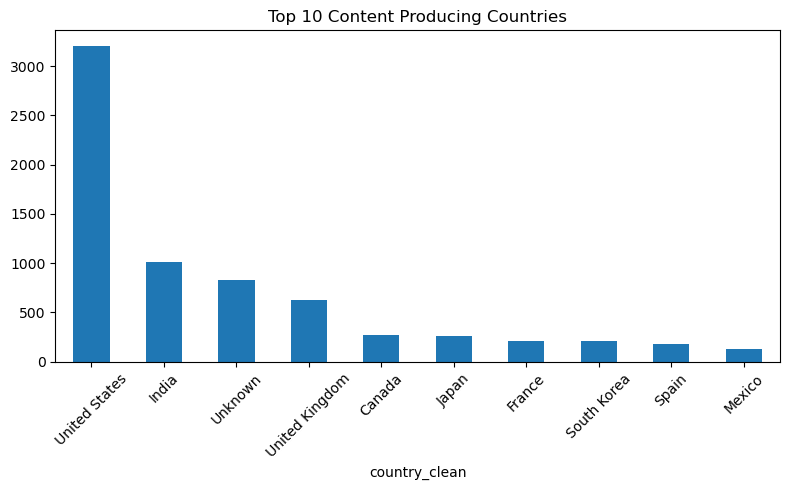

In [8]:
#Top 10 Countries (cleaned properly)
plt.figure(figsize=(8,5))

df['country_clean'] = df['country'].str.split(',').str[0]

df['country_clean'].value_counts().head(10).plot(
    kind='bar', title='Top 10 Content Producing Countries'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/Top 10 Content Producing Countries.png")
plt.show()

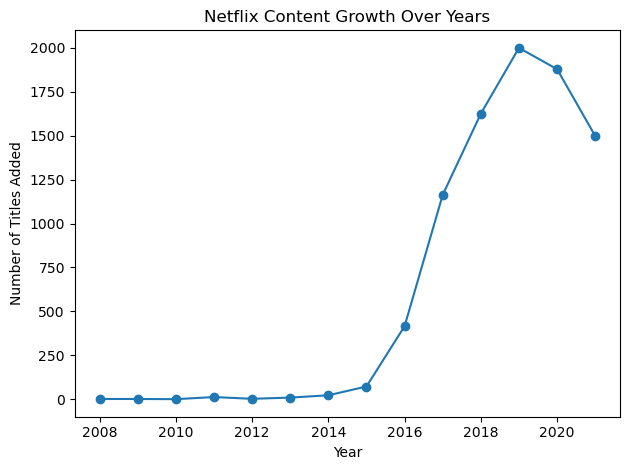

In [9]:
#. Content Growth Trend (VERY IMPORTANT)
df['year_added'].value_counts().sort_index().plot(
    kind='line', marker='o', title='Netflix Content Growth Over Years'
)
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.savefig("images/Netflix Content Growth Over Years.png")
plt.show()

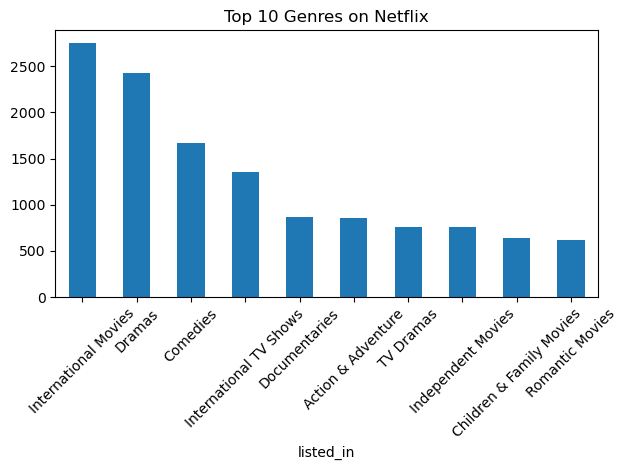

In [10]:
#Top Genres (clean properly)
genres = df['listed_in'].str.split(',').explode().str.strip()

genres.value_counts().head(10).plot(
    kind='bar', title='Top 10 Genres on Netflix'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/Top 10 Genres on Netflix.png")
plt.show()

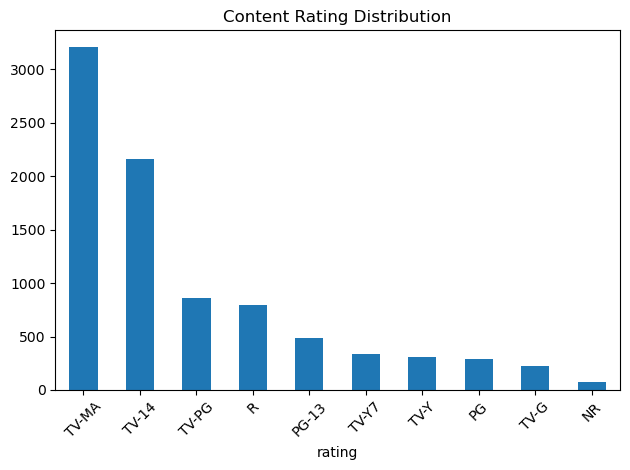

In [11]:
#5. Ratings Analysis 
df['rating'].value_counts().head(10).plot(
    kind='bar', title='Content Rating Distribution'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/Content Rating Distribution.png")
plt.show()

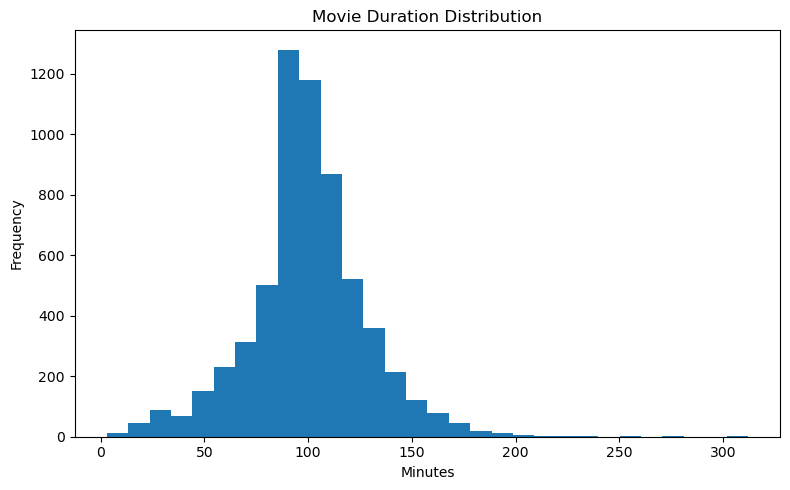

In [12]:
#Duration Analysis 
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(8,5))
movies['duration'].plot(kind='hist', bins=30)

plt.title('Movie Duration Distribution')
plt.xlabel("Minutes")

plt.tight_layout()
plt.savefig("images/movie_duration_distribution.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

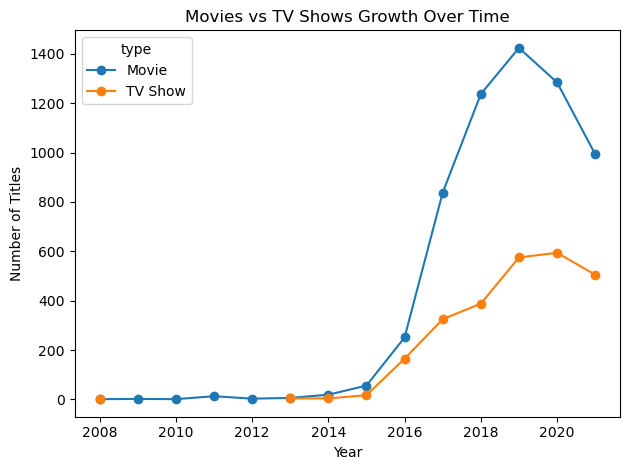

In [13]:
# Movies vs TV Shows Over Time (KEY GRAPH)
content_trend = df.groupby(['year_added', 'type']).size().unstack()

plt.figure(figsize=(10,6))
content_trend.plot(marker='o')

plt.title("Movies vs TV Shows Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.savefig("images/content_trend.png")
plt.show()

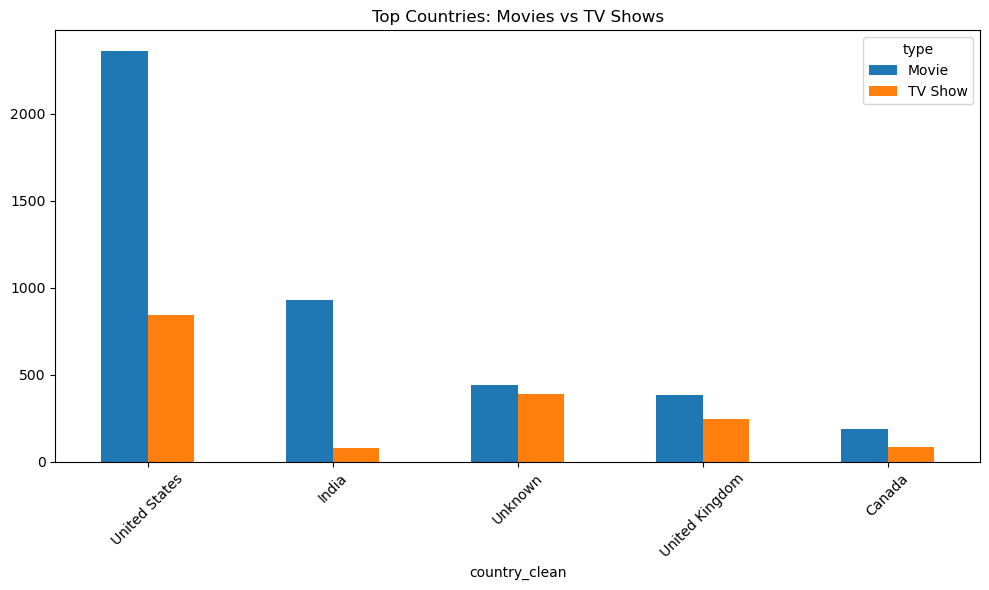

In [26]:
#Country vs Content Type
country_type = df.groupby(['country_clean', 'type']).size().unstack().fillna(0)

top_countries = df['country_clean'].value_counts().head(5).index
country_type.loc[top_countries].plot(kind='bar', figsize=(10,6))

plt.title("Top Countries: Movies vs TV Shows")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("images/country_type.png")
plt.show()

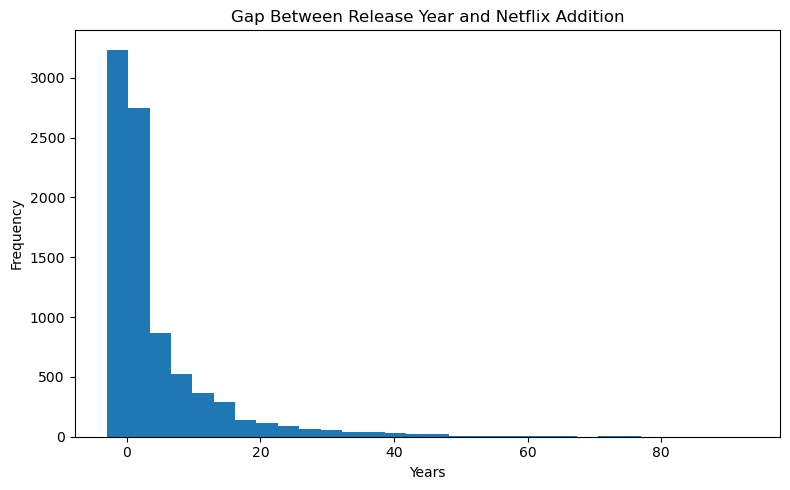

In [34]:
#Release Year vs Added Year 
df['content_age'] = df['year_added'] - df['release_year']

plt.figure(figsize=(8,5))
df['content_age'].plot(kind='hist', bins=30)

plt.title("Gap Between Release Year and Netflix Addition")
plt.xlabel("Years")

plt.tight_layout()
plt.savefig("images/content_age.png")
plt.show()

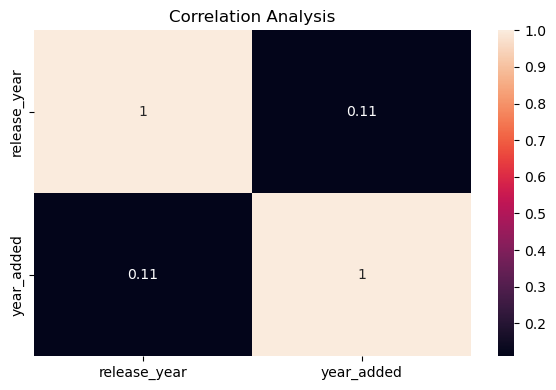

In [36]:
#Correlation Heatmap (Advanced Touch)
import seaborn as sns

numeric_df = df[['release_year', 'year_added']].dropna()

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Analysis")

plt.tight_layout()
plt.savefig("images/correlation.png")
plt.show()